Byte Pair Encoding (BPE) Tokenizer From Scratch

 The main idea behind byte pair encoding (BPE)

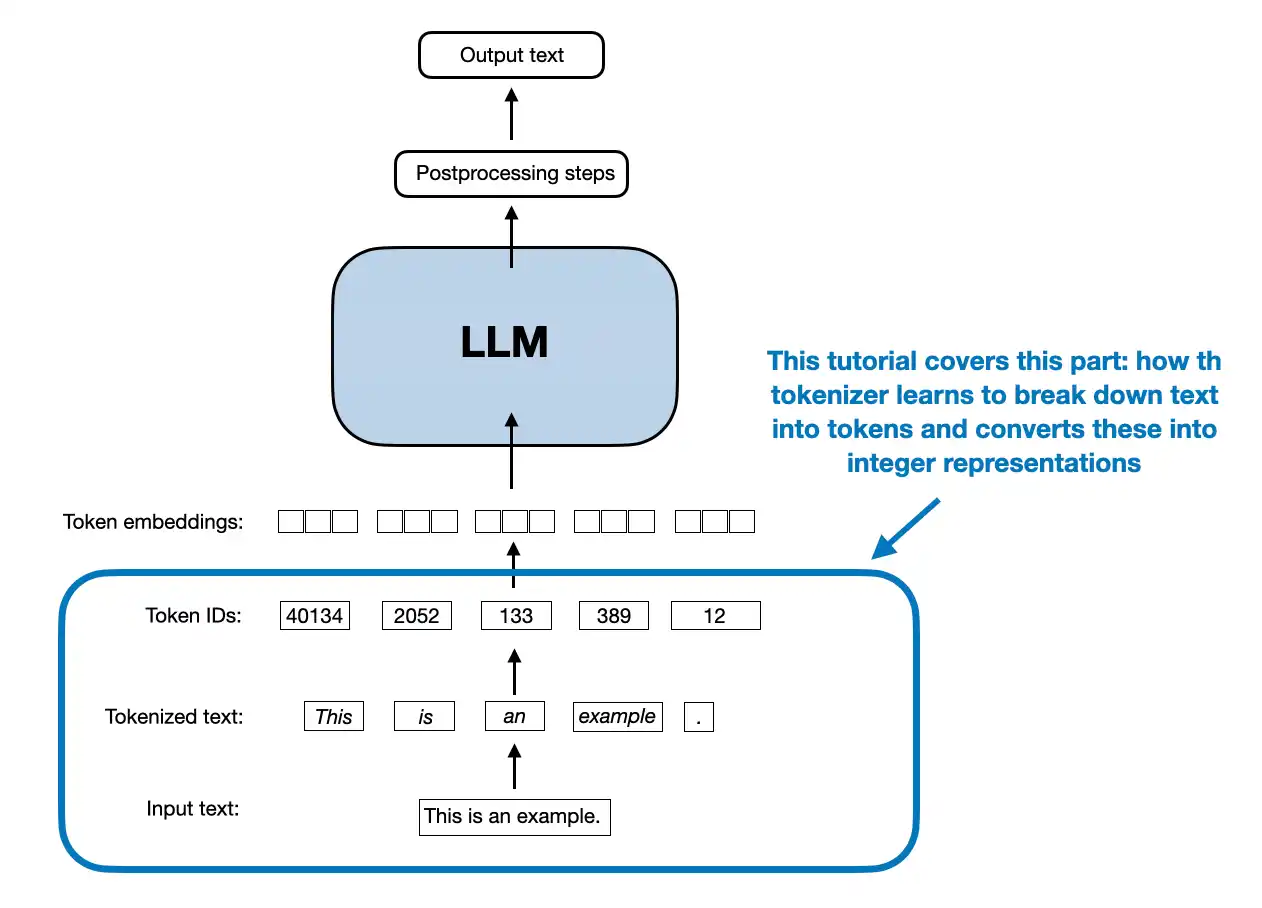

1.1 Bits and bytes

In [ ]:
# BPE 分词器的第一步：把字符串看成"字节(byte)序列"。这是 GPT-2 风格 BPE 的起点，
# 因为它以字节为最小单位，天然能表示任意 Unicode 文本，不会出现"词表外字符"的问题
text = "This is some text"
# bytearray(text, "utf-8") 按 UTF-8 编码规则把字符串转换成字节数组，
# 每个字节的取值范围是 0~255
byte_ary = bytearray(text, "utf-8")
print(byte_ary)

In [ ]:
# 把 bytearray 转成普通整数列表；这 256 个可能取值(0~255)就是 BPE 词表
# 最初、最细粒度的"基础 token"
ids = list(byte_ary)
print(ids)

In [ ]:
# 对比字符数与 token ID(字节)数：UTF-8 下非 ASCII 字符会被编码成多个字节，
# 因此字节(token)数可能大于字符数；本例全是 ASCII 字符，两者相等
print("Number of characters:", len(text))
print("Number of token IDs:", len(ids))

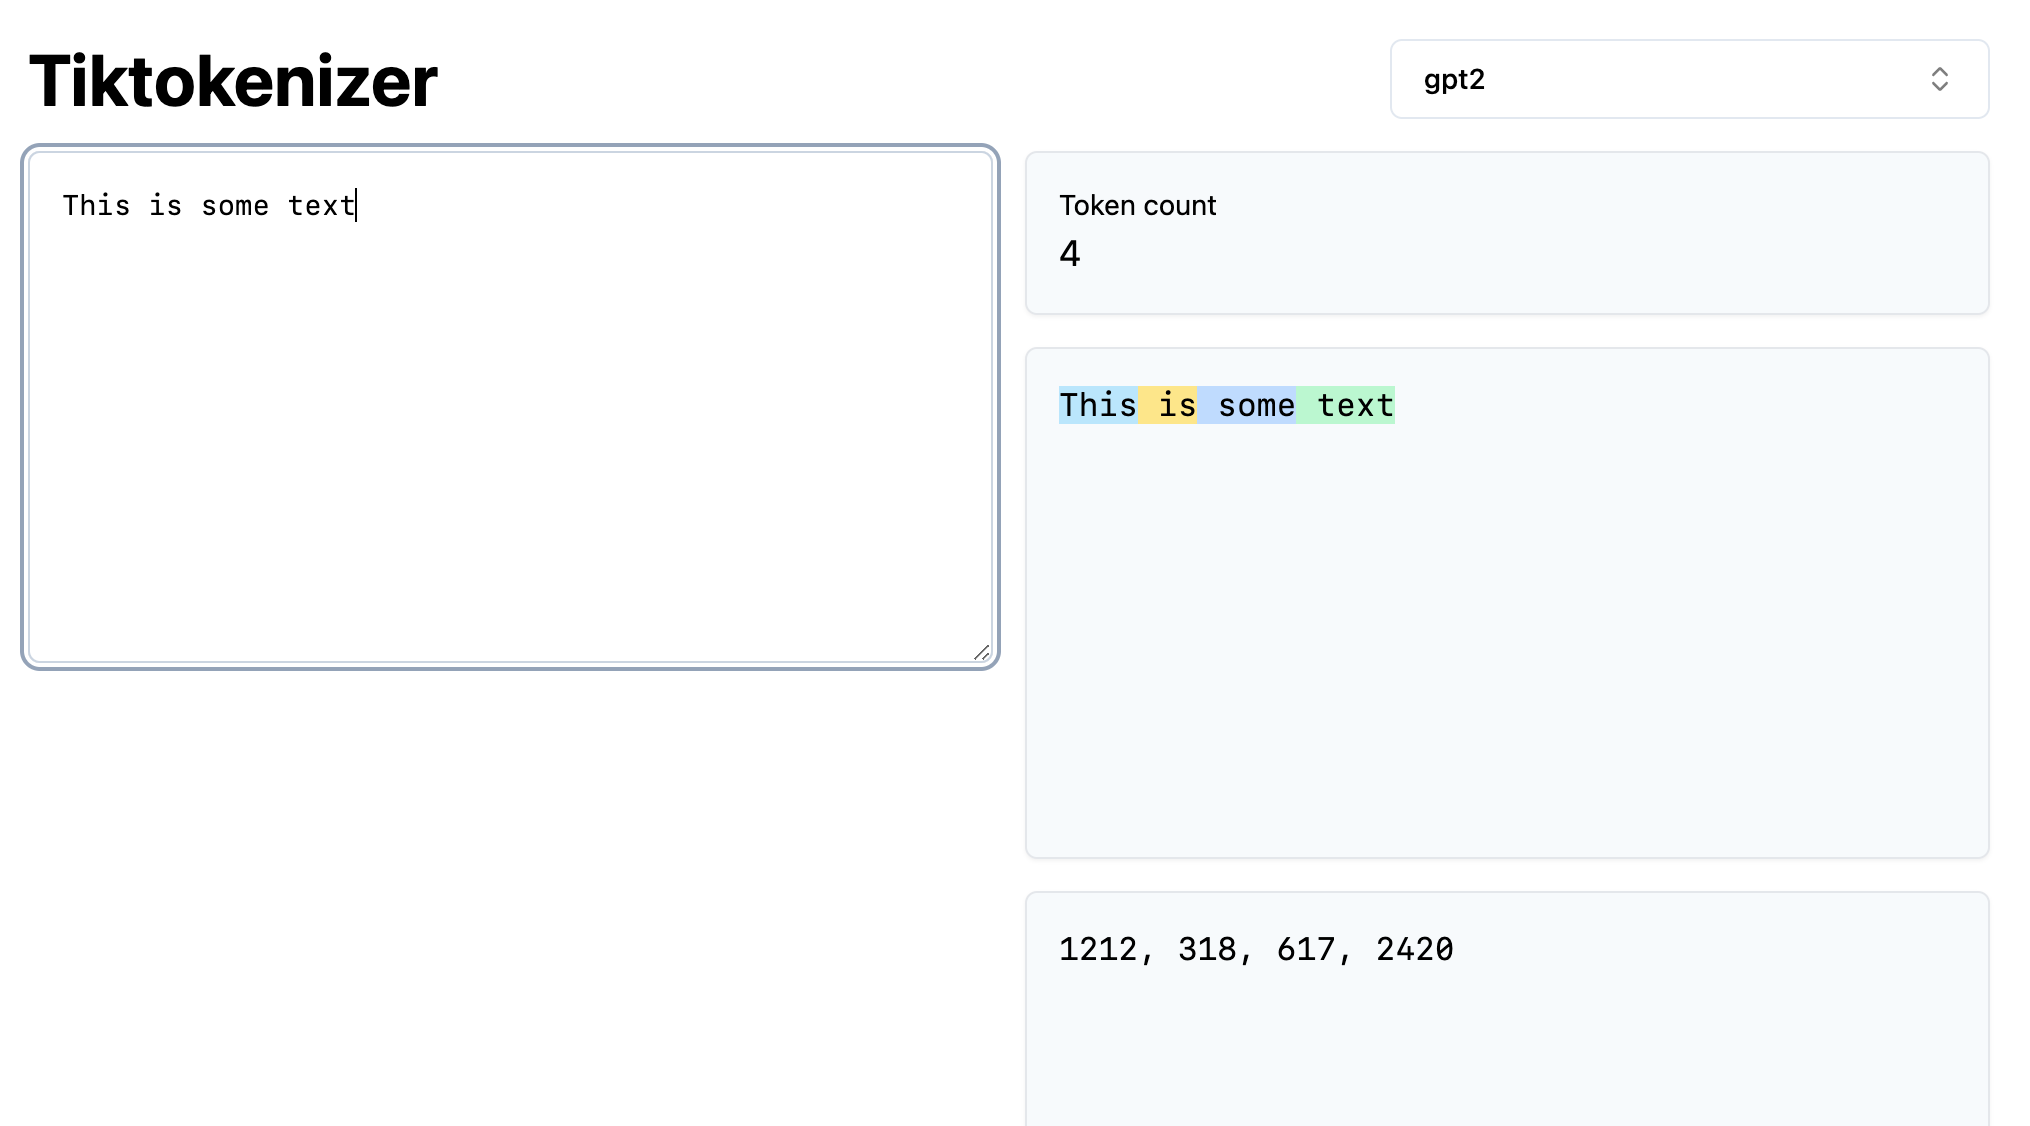

1.2 Building the vocabulary
The goal of the BPE tokenization algorithm is to build a vocabulary of commonly occurring subwords like 298: ent (which can be found in entangle, entertain, enter, entrance, entity, ..., for example), or even complete words like
318: is
617: some
1212: This
2420: text
The BPE algorithm was originally described in 1994: "A New Algorithm for Data Compression" by Philip Gage
Before we get to the actual code implementation, the form that is used for LLM tokenizers today can be summarized as described in the following sections.


1.3 BPE algorithm outline
1. Identify frequent pairs

In each iteration, scan the text to find the most commonly occurring pair of bytes (or characters)
2. Replace and record

Replace that pair with a new placeholder ID (one not already in use, e.g., if we start with 0...255, the first placeholder would be 256)
Record this mapping in a lookup table
The size of the lookup table is a hyperparameter, also called "vocabulary size" (for GPT-2, that's 50,257)
3. Repeat until no gains

Keep repeating steps 1 and 2, continually merging the most frequent pairs
Stop when no further compression is possible (e.g., no pair occurs more than once)
Decompression (decoding)

To restore the original text, reverse the process by substituting each ID with its corresponding pair, using the lookup table


1.4 BPE algorithm example
1.4.1 Concrete example of the encoding part (steps 1 & 2 in section 1.3)
Suppose we have the text (training dataset) the cat in the hat from which we want to build the vocabulary for a BPE tokenizer
Iteration 1

Identify frequent pairs
In this text, "th" appears twice (at the beginning and before the second "e")
Replace and record
replace "th" with a new token ID that is not already in use, e.g., 256
the new text is: <256>e cat in <256>e hat
the new vocabulary is
  0: ...
  ...
  256: "th"
Iteration 2

Identify frequent pairs

In the text <256>e cat in <256>e hat, the pair <256>e appears twice
Replace and record

replace <256>e with a new token ID that is not already in use, for example, 257.
The new text is:
<257> cat in <257> hat
The updated vocabulary is:
0: ...
...
256: "th"
257: "<256>e"
Iteration 3

Identify frequent pairs

In the text <257> cat in <257> hat, the pair <257>  appears twice (once at the beginning and once before “hat”).
Replace and record

replace <257>  with a new token ID that is not already in use, for example, 258.
the new text is:
<258>cat in <258>hat
The updated vocabulary is:
0: ...
...
256: "th"
257: "<256>e"
258: "<257> "
and so forth


1.4.2 Concrete example of the decoding part (step 3 in section 1.3)
To restore the original text, we reverse the process by substituting each token ID with its corresponding pair in the reverse order they were introduced
Start with the final compressed text: <258>cat in <258>hat
Substitute <258> → <257> : <257> cat in <257> hat
Substitute <257> → <256>e: <256>e cat in <256>e hat
Substitute <256> → "th": the cat in the hat


2. A simple BPE implementation
Below is an implementation of this algorithm described above as a Python class that mimics the tiktoken Python user interface
Note that the encoding part above describes the original training step via train(); however, the encode() method works similarly (although it looks a bit more complicated because of the special token handling):
Split the input text into individual bytes
Repeatedly find & replace (merge) adjacent tokens (pairs) when they match any pair in the learned BPE merges (from highest to lowest "rank," i.e., in the order they were learned)
Continue merging until no more merges can be applied
The final list of token IDs is the encoded output

In [ ]:
from collections import Counter, deque
from functools import lru_cache
import re
import json


# ========================================================================
# 从零实现一个简化版的 BPE (Byte Pair Encoding) 分词器
# 核心思想：从字符级别的小词表出发，反复统计训练语料中"相邻 token 对"的出现频率，
# 每一轮把频率最高的 pair 合并成一个新 token 并加入词表，直到词表达到目标大小；
# 这样常见的子词(如 "ing"、"ent")乃至完整单词会被合并成单个 token，从而在
# 压缩率和词表大小之间取得平衡。实现风格尽量向 OpenAI 官方 GPT-2 BPE 对齐
# (包括用 "Ġ" 表示"前面有一个空格"的约定)，因此这里训练出的分词器格式，
# 也可以直接加载 GPT-2 的官方词表(encoder.json)和合并规则(vocab.bpe)。
# ========================================================================
class BPETokenizerSimple:
    def __init__(self):
        # Maps token_id to token_str (e.g., {11246: "some"})
        self.vocab = {}
        # Maps token_str to token_id (e.g., {"some": 11246})
        self.inverse_vocab = {}
        # Dictionary of BPE merges: {(token_id1, token_id2): merged_token_id}
        self.bpe_merges = {}

        # For the official OpenAI GPT-2 merges, use a rank dict:
        #  of form {(string_A, string_B): rank}, where lower rank = higher priority
        self.bpe_ranks = {}

    def train(self, text, vocab_size, allowed_special={"<|endoftext|>"}):
        """
        Train the BPE tokenizer from scratch.

        Args:
            text (str): The training text.
            vocab_size (int): The desired vocabulary size.
            allowed_special (set): A set of special tokens to include.
        """

        # Pre-tokenize training text using the same boundary rules as encode()
        # 中文：先做"预分词"，按空白/换行边界把原始文本切成若干片段(如单词、
        # 标点、单独的换行符等)，并用 "Ġ" 前缀标记"前面带有一个空格"的片段，
        # 这一步与 encode() 中使用的规则完全一致，保证训练和推理时切分方式统一
        tokens = self.pretokenize_text(text)

        # Initialize vocab with unique characters, including "Ġ" if present
        # Start with the first 256 ASCII characters
        # 中文：词表的最底层单元是"字符"，这里先放入 0~255 号 ASCII 码位
        # 对应的字符，保证任何单字节字符都有一个基础 token
        unique_chars = [chr(i) for i in range(256)]
        unique_chars.extend(
            char for char in sorted({char for token in tokens for char in token})
            if char not in unique_chars
        )
        # 中文：再补充训练文本里出现过、但不在前 256 个 ASCII 字符里的字符
        # (例如中文、重音符号等 Unicode 字符)，保证语料中所有字符都能被表示
        if "Ġ" not in unique_chars:
            unique_chars.append("Ġ")

        # 中文：把字符列表转成 id<->字符串 的双向映射，这就是初始(未合并)词表
        self.vocab = {i: char for i, char in enumerate(unique_chars)}
        self.inverse_vocab = {char: i for i, char in self.vocab.items()}

        # Add allowed special tokens
        # 中文：把允许使用的特殊 token(如 "<|endoftext|>")作为完整的词加入词表，
        # 它们不会被拆成字符再合并，而是直接占用一个独立的 id
        if allowed_special:
            for token in allowed_special:
                if token not in self.inverse_vocab:
                    new_id = len(self.vocab)
                    self.vocab[new_id] = token
                    self.inverse_vocab[token] = new_id

        # Tokenize each pre-token into character IDs
        # 中文：把每个预分词片段拆成单个字符，再查表转换成对应的字符 id 序列；
        # 这就是 BPE 合并前，每个"词"最细粒度的 id 表示
        token_id_sequences = [
            [self.inverse_vocab[char] for char in token]
            for token in tokens
        ]

        # BPE steps 1-3: Repeatedly find and replace frequent pairs
        # 中文：BPE 训练主循环——每一轮都：
        #   1) 统计当前所有序列中，相邻 (token_id_i, token_id_i+1) 对出现的频率；
        #   2) 选出频率最高的那一对 pair_id；
        #   3) 用一个新 id 替换所有该 pair 的出现，并把这次合并记录到 bpe_merges；
        # 循环直到词表达到 vocab_size，或者已经没有可合并的相邻对为止
        for new_id in range(len(self.vocab), vocab_size):
            pair_id = self.find_freq_pair(token_id_sequences, mode="most")
            if pair_id is None:
                break
            token_id_sequences = self.replace_pair(token_id_sequences, pair_id, new_id)
            self.bpe_merges[pair_id] = new_id

        # Build the vocabulary with merged tokens
        # 中文：训练结束后，根据记录下来的每一次合并 (p0, p1) -> new_id，
        # 把 new_id 对应的字符串拼接出来(p0 的字符串 + p1 的字符串)，写入词表，
        # 这样合并出的新 token 也能像普通 token 一样通过 id<->字符串 双向查表
        for (p0, p1), new_id in self.bpe_merges.items():
            merged_token = self.vocab[p0] + self.vocab[p1]
            self.vocab[new_id] = merged_token
            self.inverse_vocab[merged_token] = new_id

    def load_vocab_and_merges_from_openai(self, vocab_path, bpe_merges_path):
        """
        Load pre-trained vocabulary and BPE merges from OpenAI's GPT-2 files.

        Args:
            vocab_path (str): Path to the vocab file (GPT-2 calls it 'encoder.json').
            bpe_merges_path (str): Path to the bpe_merges file  (GPT-2 calls it 'vocab.bpe').
        """
        # Load vocabulary
        # 中文：加载 OpenAI 官方 GPT-2 的词表文件 encoder.json，用于与官方 tokenizer 对齐
        with open(vocab_path, "r", encoding="utf-8") as file:
            loaded_vocab = json.load(file)
            # encoder.json is {token_str: id}; we want id->str and str->id
            self.vocab = {int(v): k for k, v in loaded_vocab.items()}
            self.inverse_vocab = {k: int(v) for k, v in loaded_vocab.items()}

        # Must have GPT-2's printable newline character 'Ċ' (U+010A) at id 198
        # 中文：GPT-2 用不可见字符 "Ġ"(空格) 和 "Ċ"(换行) 的"可打印替身"表示
        # 空白符，这里校验换行符对应的 id 198 是否存在，确保加载的是标准 GPT-2 词表
        if "Ċ" not in self.inverse_vocab or self.inverse_vocab["Ċ"] != 198:
            raise KeyError("Vocabulary missing GPT-2 newline glyph 'Ċ' at id 198.")

        # Must have <|endoftext|> at 50256
        # 中文：GPT-2 的文档结束特殊 token 固定为 id 50256，同样做一次校验
        if "<|endoftext|>" not in self.inverse_vocab or self.inverse_vocab["<|endoftext|>"] != 50256:
            raise KeyError("Vocabulary missing <|endoftext|> at id 50256.")

        # Provide a convenience alias for '\n' -> 198
        # Keep printable character 'Ċ' in vocab so BPE merges keep working
        # 中文：额外建立一个 "\n" -> 198 的别名映射，方便直接用真实换行符查表，
        # 但同时保留 "Ċ" 这个可打印替身，因为官方合并规则文件里用的就是 "Ċ"
        if "\n" not in self.inverse_vocab:
            self.inverse_vocab["\n"] = self.inverse_vocab["Ċ"]

        if "\r" not in self.inverse_vocab:
            if 201 in self.vocab:
                self.inverse_vocab["\r"] = 201
            else:
                raise KeyError("Vocabulary missing carriage return token at id 201.")

        # Load GPT-2 merges and store ranks
        # 中文：加载 vocab.bpe 文件，每一行是一条已经训练好的合并规则
        # "token1 token2"，行号(rank)即合并优先级——行号越小代表这条规则
        # 越早被学到、优先级越高，编码时要优先执行 rank 最小的合并
        self.bpe_ranks = {}
        with open(bpe_merges_path, "r", encoding="utf-8") as file:
            lines = file.readlines()
            if lines and lines[0].startswith("#"):
                lines = lines[1:]

            rank = 0
            for line in lines:
                token1, *rest = line.strip().split()
                if len(rest) != 1:
                    continue
                token2 = rest[0]
                if token1 in self.inverse_vocab and token2 in self.inverse_vocab:
                    self.bpe_ranks[(token1, token2)] = rank
                    rank += 1
                else:
                    # Safe to skip pairs whose symbols are not in vocab
                    pass


    def encode(self, text, allowed_special=None):
        """
        Encode the input text into a list of token IDs, with tiktoken-style handling of special tokens.

        Args:
            text (str): The input text to encode.
            allowed_special (set or None): Special tokens to allow passthrough. If None, special handling is disabled.

        Returns:
            List of token IDs.
        """

        # ---- This section is to mimic tiktoken in terms of allowed special tokens ----
        # 中文：先找出词表里所有形如 "<|xxx|>" 的特殊 token，并检查文本中是否
        # 出现了未被 allowed_special 显式允许的特殊 token，若出现则直接报错
        # (模仿 tiktoken 的行为，防止文本里意外混入未授权的控制 token)
        specials_in_vocab = [
            tok for tok in self.inverse_vocab
            if tok.startswith("<|") and tok.endswith("|>")
        ]
        if allowed_special is None:
            # Nothing is allowed
            disallowed = [tok for tok in specials_in_vocab if tok in text]
            if disallowed:
                raise ValueError(f"Disallowed special tokens encountered in text: {disallowed}")
        else:
            # Some spefic tokens are allowed (e.g., we use this for <|endoftext|>)
            disallowed = [tok for tok in specials_in_vocab if tok in text and tok not in allowed_special]
            if disallowed:
                raise ValueError(f"Disallowed special tokens encountered in text: {disallowed}")
        # -----------------------------------------------------------------------------

        token_ids = []
        # If some specials are allowed, split around them and passthrough those ids
        # 中文：如果允许某些特殊 token，就先用正则把文本按这些特殊 token 切开；
        # 特殊 token 之间的普通文本片段递归调用 encode(..., allowed_special=None)
        # 正常编码，而特殊 token 本身直接查表得到对应 id，不参与 BPE 合并
        if allowed_special is not None and len(allowed_special) > 0:
            special_pattern = "(" + "|".join(
                re.escape(tok) for tok in sorted(allowed_special, key=len, reverse=True)
            ) + ")"

            last_index = 0
            for match in re.finditer(special_pattern, text):
                prefix = text[last_index:match.start()]
                token_ids.extend(self.encode(prefix, allowed_special=None))  # encode prefix normally

                special_token = match.group(0)
                if special_token in self.inverse_vocab:
                    token_ids.append(self.inverse_vocab[special_token])
                else:
                    raise ValueError(f"Special token {special_token} not found in vocabulary.")
                last_index = match.end()

            text = text[last_index:]  # remainder to process normally

            # Extra guard for any other special literals left over
            disallowed = [
                tok for tok in self.inverse_vocab
                if tok.startswith("<|") and tok.endswith("|>") and tok in text and tok not in allowed_special
            ]
            if disallowed:
                raise ValueError(f"Disallowed special tokens encountered in text: {disallowed}")


        # ---- Newline and carriage return handling ----
        # 中文：对剩余的普通文本做与训练时一致的"预分词"(切成单词/空格/换行片段)
        tokens = self.pretokenize_text(text)
        # ---------------------------------------------------------------

        # Map tokens -> ids (BPE if needed)
        # 中文：逐个预分词片段查表；如果这个片段整体已经是词表中的一个 token
        # (比如训练/加载时已经合并出的完整单词)，直接取其 id；否则说明它
        # 还需要按 BPE 合并规则从字符级别逐步合并，调用 tokenize_with_bpe 处理
        for tok in tokens:
            if tok in self.inverse_vocab:
                token_ids.append(self.inverse_vocab[tok])
            else:
                token_ids.extend(self.tokenize_with_bpe(tok))

        return token_ids

    def tokenize_with_bpe(self, token):
        """
        Tokenize a single token using BPE merges.

        Args:
            token (str): The token to tokenize.

        Returns:
            List[int]: The list of token IDs after applying BPE.
        """
        # Tokenize the token into individual characters (as initial token IDs)
        # 中文：先把这个 token 拆成单个字符，并查表得到每个字符对应的 id，
        # 作为后续合并的起点(与训练阶段的初始化方式一致)
        token_ids = [self.inverse_vocab.get(char, None) for char in token]
        if None in token_ids:
            missing_chars = [char for char, tid in zip(token, token_ids) if tid is None]
            raise ValueError(f"Characters not found in vocab: {missing_chars}")

        # If we haven't loaded OpenAI's GPT-2 merges, use my approach
        # 中文：分支一——使用自己训练得到的 bpe_merges 字典 {(id1, id2): 合并后的id}。
        # 这里简单地反复从左到右扫描，只要相邻 (id_i, id_i+1) 在 bpe_merges 中
        # 出现就合并，直到没有可合并的为止
        if not self.bpe_ranks:
            can_merge = True
            while can_merge and len(token_ids) > 1:
                can_merge = False
                new_tokens = []
                i = 0
                while i < len(token_ids) - 1:
                    pair = (token_ids[i], token_ids[i + 1])
                    if pair in self.bpe_merges:
                        merged_token_id = self.bpe_merges[pair]
                        new_tokens.append(merged_token_id)
                        # Uncomment for educational purposes:
                        # print(f"Merged pair {pair} -> {merged_token_id} ('{self.vocab[merged_token_id]}')")
                        i += 2  # Skip the next token as it's merged
                        can_merge = True
                    else:
                        new_tokens.append(token_ids[i])
                        i += 1
                if i < len(token_ids):
                    new_tokens.append(token_ids[i])
                token_ids = new_tokens
            return token_ids

        # Otherwise, do GPT-2-style merging with the ranks:
        # 中文：分支二——使用加载进来的官方 GPT-2 合并规则表 bpe_ranks，更严格地
        # 复现 GPT-2 的合并顺序：每一轮都要在所有当前相邻 pair 中，找出 rank
        # 最小(即在官方 vocab.bpe 文件中出现得最早、优先级最高)的那一对，
        # 先合并它，而不是简单地按位置从左到右扫描一遍就合并
        # 1) Convert token_ids back to string "symbols" for each ID
        symbols = [self.vocab[id_num] for id_num in token_ids]

        # Repeatedly merge all occurrences of the lowest-rank pair
        while True:
            # Collect all adjacent pairs
            # 中文：收集当前 symbols 序列里所有相邻的 (symbol_i, symbol_i+1) 对
            pairs = set(zip(symbols, symbols[1:]))
            if not pairs:
                break

            # Find the pair with the best (lowest) rank
            # 中文：在所有候选 pair 中，选出 rank 最小(优先级最高)的那一对；
            # 如果某个 pair 不在 bpe_ranks 里，用 +inf 表示它不可合并
            min_rank = float("inf")
            bigram = None
            for p in pairs:
                r = self.bpe_ranks.get(p, float("inf"))
                if r < min_rank:
                    min_rank = r
                    bigram = p

            # If no valid ranked pair is present, we're done
            if bigram is None or bigram not in self.bpe_ranks:
                break

            # Merge all occurrences of that pair
            # 中文：把 symbols 序列中所有这个 (first, second) pair 的出现都
            # 合并成一个新的字符串 symbol(直接做字符串拼接)，完成这一轮合并
            first, second = bigram
            new_symbols = []
            i = 0
            while i < len(symbols):
                # If we see (first, second) at position i, merge them
                if i < len(symbols) - 1 and symbols[i] == first and symbols[i+1] == second:
                    new_symbols.append(first + second)  # merged symbol
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            symbols = new_symbols

            if len(symbols) == 1:
                break

        # Finally, convert merged symbols back to IDs
        # 中文：合并结束后，把最终的字符串 symbols 逐个转换回词表 id
        merged_ids = [self.inverse_vocab[sym] for sym in symbols]
        return merged_ids

    def decode(self, token_ids):
        """
        Decode a list of token IDs back into a string.

        Args:
            token_ids (List[int]): The list of token IDs to decode.

        Returns:
            str: The decoded string.
        """
        # 中文：解码是编码的逆过程——把每个 id 查表还原成对应的 token 字符串，
        # 再把所有字符串拼接起来；注意要把 "Ġ"(代表前导空格)、id 198/"Ċ"(换行)、
        # id 201(回车) 这些 GPT-2 特有的"可打印替身"还原成真正的空白字符
        out = []
        for tid in token_ids:
            if tid not in self.vocab:
                raise ValueError(f"Token ID {tid} not found in vocab.")
            tok = self.vocab[tid]

            # Map GPT-2 special chars back to real chars
            if tid == 198 or tok == "\n":
                out.append("\n")
            elif tid == 201 or tok == "\r":
                out.append("\r")
            elif tok.startswith("Ġ"):
                out.append(" " + tok[1:])
            else:
                out.append(tok)
        return "".join(out)

    def save_vocab_and_merges(self, vocab_path, bpe_merges_path):
        """
        Save the vocabulary and BPE merges to JSON files.

        Args:
            vocab_path (str): Path to save the vocabulary.
            bpe_merges_path (str): Path to save the BPE merges.
        """
        # Save vocabulary
        # 中文：把 id -> token 字符串 的词表以 JSON 形式落盘，方便之后直接加载复用
        with open(vocab_path, "w", encoding="utf-8") as file:
            json.dump(self.vocab, file, ensure_ascii=False, indent=2)

        # Save BPE merges as a list of dictionaries
        # 中文：把合并规则 {(id1, id2): new_id} 转成有序列表再保存，
        # 保留训练时的合并顺序(即合并的优先级顺序)，加载时按同样顺序还原
        with open(bpe_merges_path, "w", encoding="utf-8") as file:
            merges_list = [{"pair": list(pair), "new_id": new_id}
                           for pair, new_id in self.bpe_merges.items()]
            json.dump(merges_list, file, ensure_ascii=False, indent=2)

    def load_vocab_and_merges(self, vocab_path, bpe_merges_path):
        """
        Load the vocabulary and BPE merges from JSON files.

        Args:
            vocab_path (str): Path to the vocabulary file.
            bpe_merges_path (str): Path to the BPE merges file.
        """
        # Load vocabulary
        # 中文：加载之前用 save_vocab_and_merges 保存的自训练词表和合并规则
        with open(vocab_path, "r", encoding="utf-8") as file:
            loaded_vocab = json.load(file)
            self.vocab = {int(k): v for k, v in loaded_vocab.items()}
            self.inverse_vocab = {v: int(k) for k, v in loaded_vocab.items()}

        # Load BPE merges
        with open(bpe_merges_path, "r", encoding="utf-8") as file:
            merges_list = json.load(file)
            for merge in merges_list:
                pair = tuple(merge["pair"])
                new_id = merge["new_id"]
                self.bpe_merges[pair] = new_id

    @lru_cache(maxsize=None)
    def get_special_token_id(self, token):
        # 中文：根据特殊 token 字符串查询其 id；用 lru_cache 缓存结果避免重复查表
        return self.inverse_vocab.get(token, None)

    @staticmethod
    def pretokenize_text(text):
        # 中文：预分词——把原始文本切成一串"片段"(token 的候选单位)，规则尽量
        # 对齐 GPT-2 的做法：
        #   1) 先按换行符 \r\n / \r / \n 切分，换行符本身单独作为一个片段；
        #   2) 每一段不含换行的文本，再按"连续空格"与"非空格序列"切分：
        #      单词前面若有空格，用 "Ġ" 前缀标记"这个词前面有一个空格"(GPT-2 里
        #      空格不单独成词，而是"贴"在后面单词开头)，多余的空格则各自变成
        #      独立的 "Ġ" 占位 token(对应官方 tiktoken 中常见的 id 220)
        tokens = []
        parts = re.split(r'(\r\n|\r|\n)', text)
        for part in parts:
            if part == "":
                continue
            if part == "\r\n":
                tokens.append("\r")
                tokens.append("\n")
                continue
            if part == "\r":
                tokens.append("\r")
                continue
            if part == "\n":
                tokens.append("\n")
                continue

            # Normal chunk without line breaks:
            # - If spaces precede a word, prefix the first word with 'Ġ' and
            #   add standalone 'Ġ' for additional spaces
            # - If spaces trail the chunk (e.g., before a newline) add
            #   standalone 'Ġ' tokens (tiktoken produces id 220 for 'Ġ')
            pending_spaces = 0
            for m in re.finditer(r'( +)|(\S+)', part):
                if m.group(1) is not None:
                    pending_spaces += len(m.group(1))
                else:
                    word = m.group(2)
                    if pending_spaces > 0:
                        for _ in range(pending_spaces - 1):
                            tokens.append("Ġ")  # remaining spaces as standalone
                        tokens.append("Ġ" + word) # one leading space
                        pending_spaces = 0
                    else:
                        tokens.append(word)
            # Trailing spaces (no following word): add standalone 'Ġ' tokens
            for _ in range(pending_spaces):
                tokens.append("Ġ")
        return tokens

    @staticmethod
    def find_freq_pair(token_id_sequences, mode="most"):
        # 中文：统计所有 token_id 序列中"相邻两个 id"组成的 pair 出现的次数，
        # 这是 BPE 训练每一轮的第一步：找出当前最值得合并(或最不值得，用于
        # 调试/研究)的相邻 pair
        pairs = Counter(
            pair
            for token_ids in token_id_sequences
            for pair in zip(token_ids, token_ids[1:])
        )

        if not pairs:
            return None

        if mode == "most":
            return max(pairs.items(), key=lambda x: x[1])[0]
        elif mode == "least":
            return min(pairs.items(), key=lambda x: x[1])[0]
        else:
            raise ValueError("Invalid mode. Choose 'most' or 'least'.")

    @staticmethod
    def replace_pair(token_id_sequences, pair_id, new_id):
        # 中文：把每条序列中所有出现的 pair_id = (a, b) 替换成新的 new_id，
        # 用 deque 从左到右扫描：一旦当前元素和下一个元素恰好组成 pair_id，
        # 就把它们合并为 new_id 并跳过被合并掉的那个元素，否则原样保留
        replaced_sequences = []

        for token_ids in token_id_sequences:
            dq = deque(token_ids)
            replaced = []

            while dq:
                current = dq.popleft()
                if dq and (current, dq[0]) == pair_id:
                    replaced.append(new_id)
                    # Remove the 2nd token of the pair, 1st was already removed
                    dq.popleft()
                else:
                    replaced.append(current)

            replaced_sequences.append(replaced)

        return replaced_sequences

3. BPE implementation walkthrough
In practice, I highly recommend using tiktoken as my implementation above focuses on readability and educational purposes, not on performance
However, the usage is more or less similar to tiktoken, except that tiktoken does not have a training method
Let's see how my BPETokenizerSimple Python code above works by looking at some examples below (a detailed code discussion is out of scope for this notebook)
3.1 Training, encoding, and decoding


In [ ]:
import os
import requests

# 中文：辅助函数——如果指定的文件在若干候选目录中已存在就直接复用，
# 否则从 url 下载到第一个候选目录下；这里用来获取训练 BPE 分词器所需的语料文件
def download_file_if_absent(url, filename, search_dirs):
    for directory in search_dirs:
        file_path = os.path.join(directory, filename)
        if os.path.exists(file_path):
            print(f"{filename} already exists in {file_path}")
            return file_path

    target_path = os.path.join(search_dirs[0], filename)
    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()
        with open(target_path, "wb") as out_file:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    out_file.write(chunk)
        print(f"Downloaded {filename} to {target_path}")
    except Exception as e:
        print(f"Failed to download {filename}. Error: {e}")

    return target_path


# 中文：下载(或复用本地已有的) the-verdict.txt 短篇小说文本，作为下面 BPE 训练的语料
verdict_path = download_file_if_absent(
    url=(
         "https://raw.githubusercontent.com/rasbt/"
         "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
         "the-verdict.txt"
    ),
    filename="the-verdict.txt",
    search_dirs=["ch02/01_main-chapter-code/", "../01_main-chapter-code/", "."]
)

# 中文：读入训练语料的完整文本，后面调用 tokenizer.train(text, ...) 会用到
with open(verdict_path, "r", encoding="utf-8") as f: # added ../01_main-chapter-code/
    text = f.read()

In [ ]:
# 中文：实例化分词器并在语料 text 上训练；vocab_size=1000 表示训练结束后
# 词表共有 1000 个 token(256 个基础字符 + "Ġ" + 特殊 token + 训练中学到的合并 token)
tokenizer = BPETokenizerSimple()
tokenizer.train(text, vocab_size=1000, allowed_special={"<|endoftext|>"})

In [ ]:
# 中文：打印最终词表大小，应当等于训练时设置的 vocab_size(=1000)
print(len(tokenizer.vocab))

In [ ]:
# 中文：打印一共学到了多少条"合并规则"；大致等于 vocab_size 减去
# 初始词表大小(256 个字符 + "Ġ" + 特殊 token)
print(len(tokenizer.bpe_merges))

In [ ]:
# 中文：用训练好的分词器对一句新文本编码，得到对应的 token id 序列(不含特殊 token)
input_text = "Jack embraced beauty through art and life."
token_ids = tokenizer.encode(input_text)
print(token_ids)

In [ ]:
# 中文：这次文本末尾带有特殊 token "<|endoftext|>"，需要通过 allowed_special
# 显式允许它通过，否则 encode() 会因检测到未授权的特殊 token 而报错
input_text = "Jack embraced beauty through art and life.<|endoftext|> "
token_ids = tokenizer.encode(input_text, allowed_special={"<|endoftext|>"})
print(token_ids)

In [ ]:
# 中文：对比原始字符数与 BPE 编码后的 token 数，直观感受 BPE 的压缩效果
# (常见子词/单词被合并成了单个 token，因此 token 数通常明显少于字符数)
print("Number of characters:", len(input_text))
print("Number of token IDs:", len(token_ids))

In [ ]:
# 中文：再次打印上一格得到的 token id 序列，方便与下面逐个解码的结果对照
print(token_ids)

In [ ]:
# 中文：把 token id 序列解码还原成文本，验证编码/解码是否可逆
print(tokenizer.decode(token_ids))

In [ ]:
# 中文：逐个展示每一个 token id 还原出的子串，可以直观看到哪些字符被合并成
# 了一个 token(例如常见单词或子词)，哪些仍然是单个字符
for token_id in token_ids:
    print(f"{token_id} -> {tokenizer.decode([token_id])}")

In [ ]:
# 中文：编码后立刻解码，验证"编码->解码"的往返一致性(round-trip)
tokenizer.decode(
    tokenizer.encode("This is some text.")
)

In [ ]:
# 中文：验证包含换行符的文本也能正确地编码再解码回原文；换行符会被
# pretokenize_text 单独处理成一个 "\n" token
tokenizer.decode(
    tokenizer.encode("This is some text with \n newline characters.")
)

3.2 Saving and loading the tokenizer

In [ ]:
# Save trained tokenizer
# 中文：把训练好的词表和合并规则保存到磁盘，方便下次直接加载而无需重新训练
tokenizer.save_vocab_and_merges(vocab_path="vocab.json", bpe_merges_path="bpe_merges.txt")

In [ ]:
# Load tokenizer
# 中文：新建一个空的分词器实例，并从磁盘加载刚才保存的词表和合并规则，
# 验证保存/加载流程是否完整可用
tokenizer2 = BPETokenizerSimple()
tokenizer2.load_vocab_and_merges(vocab_path="vocab.json", bpe_merges_path="bpe_merges.txt")

In [ ]:
# 中文：用重新加载出来的 tokenizer2 解码之前的 token_ids，结果应与
# tokenizer 一致，说明保存/加载没有丢失信息
print(tokenizer2.decode(token_ids))

In [ ]:
# 中文：再次验证加载后的 tokenizer2 在处理换行符时的编码/解码往返一致性
tokenizer2.decode(
    tokenizer2.encode("This is some text with \n newline characters.")
)

3.3 Loading the original GPT-2 BPE tokenizer from OpenAI

In [ ]:
# Download files if not already present in this directory
# 中文：下载 OpenAI 官方发布的 GPT-2 (124M) 分词器文件：encoder.json(词表)
# 和 vocab.bpe(合并规则)，用于下面加载"官方标准"的 BPE 分词器，
# 与本 notebook 里自己训练的简化版分词器做对比

# Define the directories to search and the files to download
search_directories = ["ch02/02_bonus_bytepair-encoder/gpt2_model/", "../02_bonus_bytepair-encoder/gpt2_model/", "."]

files_to_download = {
    "https://openaipublic.blob.core.windows.net/gpt-2/models/124M/vocab.bpe": "vocab.bpe",
    "https://openaipublic.blob.core.windows.net/gpt-2/models/124M/encoder.json": "encoder.json"
}

# Ensure directories exist and download files if needed
# 中文：依次下载(或复用本地已有的)两个文件，paths 保存每个文件最终的本地路径
paths = {}
for url, filename in files_to_download.items():
    paths[filename] = download_file_if_absent(url, filename, search_directories)

In [ ]:
# 中文：新建一个分词器实例，加载 OpenAI 官方 GPT-2 词表与合并规则(而不是
# 自己训练)，这样得到的编码结果会与真正的 GPT-2 / tiktoken 完全一致
tokenizer_gpt2 = BPETokenizerSimple()
tokenizer_gpt2.load_vocab_and_merges_from_openai(
    vocab_path=paths["encoder.json"], bpe_merges_path=paths["vocab.bpe"]
)

In [ ]:
# 中文：GPT-2 官方词表大小应为 50257(50000 条 BPE 合并 token +
# 256 个基础字节 token + 1 个 <|endoftext|>)
len(tokenizer_gpt2.vocab)

In [ ]:
# 中文：用加载的官方 GPT-2 分词器对同一句文本编码，可与 tiktoken 的
# 输出核对是否一致
input_text = "This is some text"
token_ids = tokenizer_gpt2.encode(input_text)
print(token_ids)

In [ ]:
# 中文：解码验证，确认加载的官方 GPT-2 分词器编码/解码同样往返一致
print(tokenizer_gpt2.decode(token_ids))

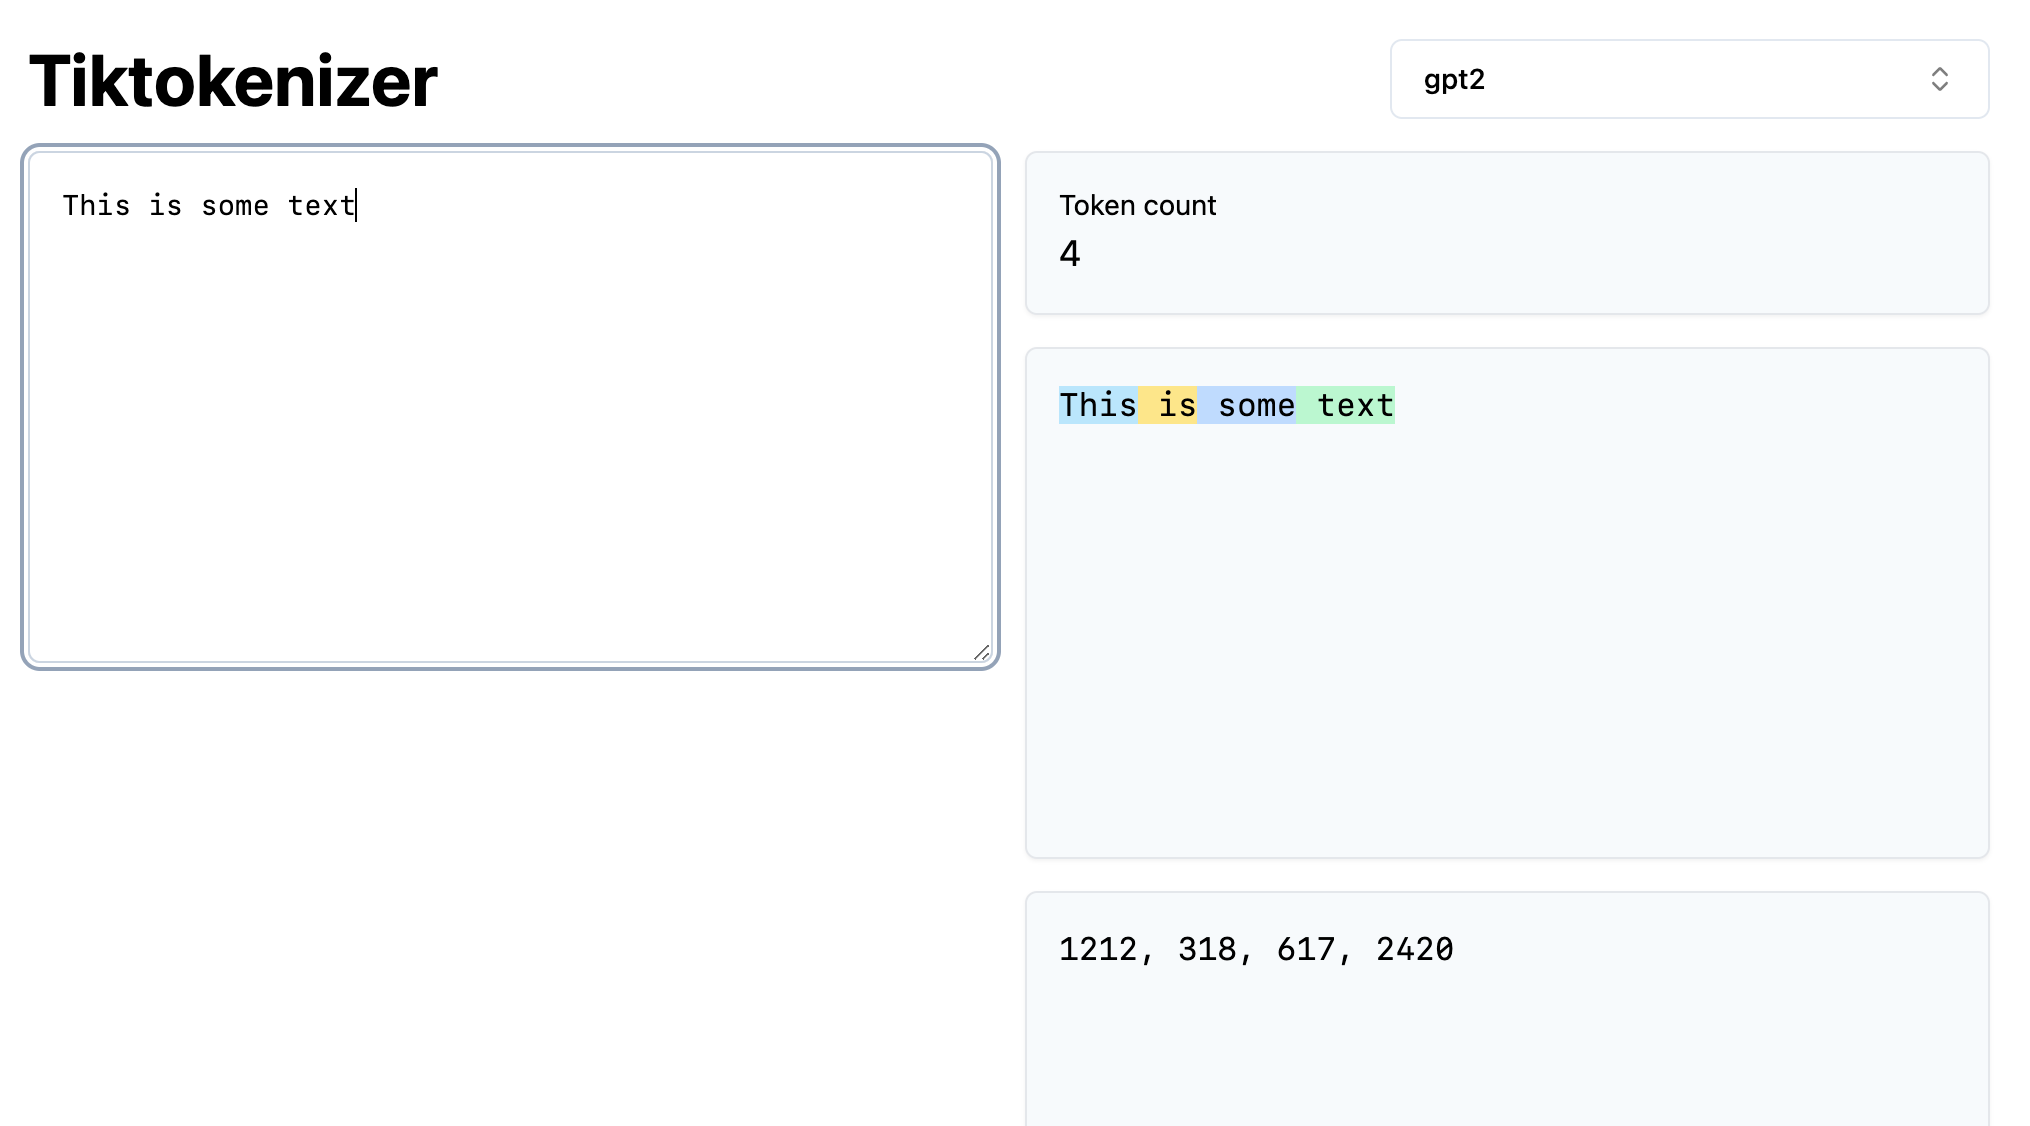